## Research Question
This project aims to answer the following questions:
1. Is the proportion of students who felt sad or hopeless different from 0.30?
2. Is the average height of students different from 1.70 meters?

## Variable Definition
SadOrHopeless:
This variable measures whether a student felt sad or hopeless.
Code 1 = Yes (success), Code 2 = No (failure).
Missing values are removed.

HowTallAreYouWithoutShoesInMeters:
This variable measures student height in meters.
Missing values are removed before analysis.

In [107]:
## Variable Definition and Data Check

import pandas as pd
import numpy as np

df = pd.read_csv("YRBS_2007.csv")

# --- SadOrHopeless ---
# 1 = Yes (Success), 2 = No (Failure)

print("SadOrHopeless 原始分布（含 missing）:")
print(df["SadOrHopeless"].value_counts(dropna=False))

print("\nMissing values:")
print(df["SadOrHopeless"].isna().sum())

# 清理資料
df_prop = df["SadOrHopeless"].dropna()
df_prop = df_prop[df_prop.isin([1, 2])]

# binary recoding
df_prop_binary = df_prop.replace({1:1, 2:0})

print("\nBinary 後分布:")
print(df_prop_binary.value_counts())

print("\n樣本數:", len(df_prop_binary))

SadOrHopeless 原始分布（含 missing）:
SadOrHopeless
2.0    9692
1.0    4153
NaN     196
Name: count, dtype: int64

Missing values:
196

Binary 後分布:
SadOrHopeless
0.0    9692
1.0    4153
Name: count, dtype: int64

樣本數: 13845


In [109]:
# 2. 身高變數定義
print("\nHeight missing values:")
print(df["HowTallAreYouWithoutShoesInMeters"].isna().sum())

df_height = df["HowTallAreYouWithoutShoesInMeters"].dropna()

print("樣本數:", len(df_height))


Height missing values:
979
樣本數: 13062


比例:
SadOrHopeless
0.0    0.700036
1.0    0.299964
Name: proportion, dtype: float64


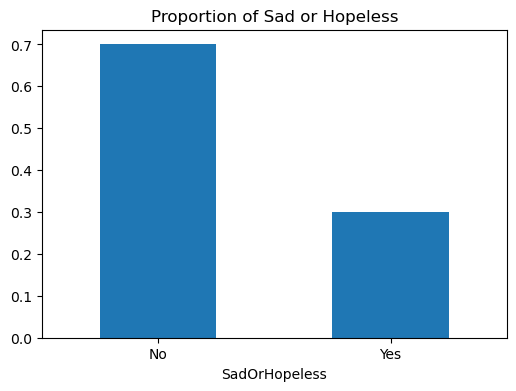

In [111]:
# (1) 憂鬱比例長條圖
import matplotlib.pyplot as plt

## EDA: Proportion

print("比例:")
print(df_prop_binary.value_counts(normalize=True))

plt.figure(figsize=(6,4))
df_prop_binary.value_counts(normalize=True).plot(kind='bar')
plt.xticks([0,1], ['No','Yes'], rotation=0)
plt.title("Proportion of Sad or Hopeless")
plt.show()
# 觀察：樣本比例約為 0.30，與基準值高度吻合。

count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


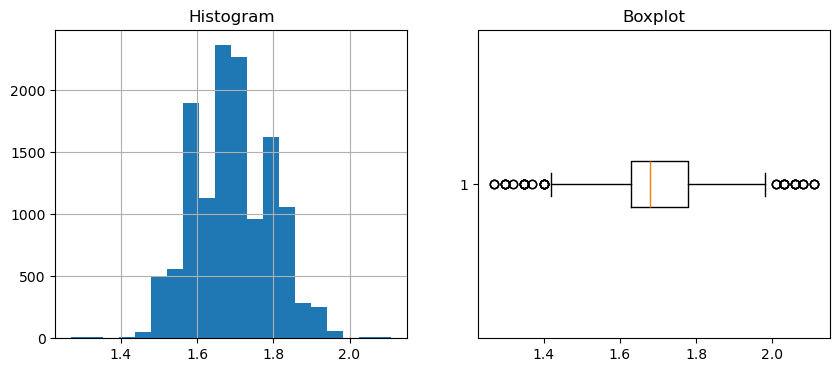

In [113]:
# (2) 身高分佈圖
print(df_height.describe())
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df_height.hist(bins=20)
plt.title("Histogram")

plt.subplot(1,2,2)
plt.boxplot(df_height, vert=False)
plt.title("Boxplot")

plt.show()
# 觀察：身高呈常態分佈，中位數與平均數接近，無極端離群值。

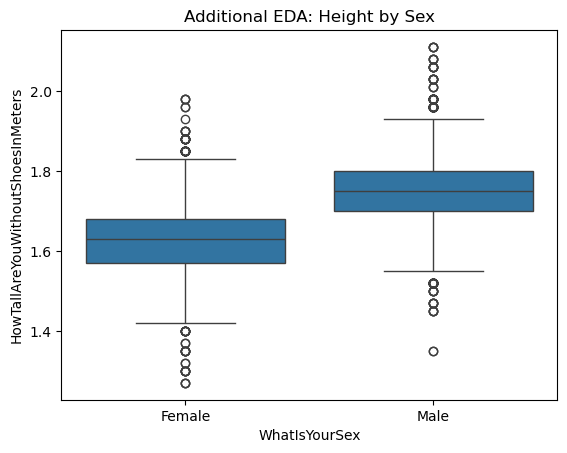

In [115]:
# (3) [自選探索] 按性別看身高差異
sns.boxplot(x='WhatIsYourSex', y='HowTallAreYouWithoutShoesInMeters', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Additional EDA: Height by Sex")
plt.show()
# 觀察：男生的身高分佈明顯高於女生。

In [97]:
# --- 比例檢定 ---
p_hat = df_prop_binary.mean()
n_p = len(df_prop_binary)
p0 = 0.30
z_stat = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n_p)
p_val_p = 2 * (1 - norm.cdf(abs(z_stat)))
ci_p = (p_hat - 1.96 * np.sqrt(p_hat*(1-p_hat)/n_p), p_hat + 1.96 * np.sqrt(p_hat*(1-p_hat)/n_p))

print(f"比例分析: p-hat={p_hat:.4f}, p-value={p_val_p:.4f}, CI={ci_p}")

比例分析: p-hat=0.3000, p-value=0.9926, CI=(0.2923307270442763, 0.30759704471448135)


In [99]:
# --- 平均數檢定 ---
mean_h = df_height.mean()
std_h = df_height.std()
n_h = len(df_height)
mu0 = 1.70
t_stat = (mean_h - mu0) / (std_h / np.sqrt(n_h))
p_val_h = 2 * (1 - t.cdf(abs(t_stat), df=n_h-1))
ci_h = (mean_h - 1.96 * (std_h/np.sqrt(n_h)), mean_h + 1.96 * (std_h/np.sqrt(n_h)))

print(f"平均數分析: mean={mean_h:.4f}, p-value={p_val_h:.11f}, CI={ci_h}")

平均數分析: mean=1.6940, p-value=0.00000000002, CI=(1.6922975769307675, 1.6957777560963336)


In [117]:
summary = pd.DataFrame({
    "Analysis": ["Proportion", "Mean"],
    "Estimate": [p_hat, mean_h],
    "CI Lower": [ci_p[0], ci_h[0]],
    "CI Upper": [ci_p[1], ci_h[1]],
    "p-value": [p_val_p, p_val_h]
})

print(summary)

     Analysis  Estimate  CI Lower  CI Upper       p-value
0  Proportion  0.299964  0.292331  0.307597  9.926014e-01
1        Mean  1.694038  1.692298  1.695778  1.947176e-11


In [ ]:
## Final Interpretation

# Proportion:
# The 95% confidence interval includes 0.30.
# The p-value is greater than 0.05, so we fail to reject the null hypothesis.
# This suggests that the proportion is not significantly different from 0.30.
# This result is consistent with the EDA.

# Mean:
# The 95% confidence interval does not include 1.70.
# The p-value is very small, so we reject the null hypothesis.
# This suggests that the mean height is significantly different from 1.70.
# The mean appears slightly lower than 1.70, which matches the EDA.

# Overall:
# The EDA and inference results are consistent.
# However, results should be interpreted with caution due to missing values and self-reported data.